## 1. Data Loading

In [12]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

air_quality= fetch_ucirepo(id=360)
data = air_quality.data.features

print(f"Dataset shape: {data.shape}")
print(f"Column names:")
print(data.columns.tolist())

Dataset shape: (9357, 15)
Column names:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


## 2. Data Processing

### Step 1: DateTime Consolidation

Merge the separate Date and Time columns into a single DateTime column and set it as the index for time series analysis. Note that the actual date range spans from March 2004 to April 2005, which differs from the project description.

In [13]:
# Merge Date and Time columns
data['DateTime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='mixed')

# Drop original Date and Time columns
data = data.drop(['Date', 'Time'], axis=1)

# Set DateTime as index
data = data.set_index('DateTime')

print("Date range:")
print(f"Start: {data.index.min()}")
print(f"End: {data.index.max()}")
print(f"Total duration: {data.index.max() - data.index.min()}")

Date range:
Start: 2004-03-10 18:00:00
End: 2005-04-04 14:00:00
Total duration: 389 days 20:00:00


### Step 2: Missing Value Imputation

Handle missing values (represented as -200) through linear interpolation. Note that NMHC(GT) contains an excessive number of missing values (8443 out of 9357), rendering it practically unusable for analysis.

The interpolation preserves original data types to maintain consistency throughout the dataset.

In [14]:

# Check missing values (-200) before processing
print("Missing values count (-200):")
missing_counts = (data == -200.0).sum()
print(missing_counts)
print(f"\nTotal missing values: {missing_counts.sum()}")

# Store original data types before interpolation
original_dtypes = data.dtypes.copy()

# Replace -200 with NaN
data = data.replace(-200.0, np.nan)

# Interpolate missing values using linear interpolation
data = data.interpolate(method='linear', limit_direction='both')

# Restore original data types (convert int columns back to int)
for col in data.columns:
    if original_dtypes[col] in ['int64', 'int32', 'int16', 'int8']:
        data[col] = data[col].round().astype(original_dtypes[col])

Missing values count (-200):
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Total missing values: 16701


### Step 3: Temporal Feature Engineering

Extract temporal features from the DateTime index, including hour of day, day of week, and month. These features enable the model to capture temporal patterns in air quality measurements.

In [15]:
# Extract time-based features from DateTime index
data['Hour'] = data.index.hour
data['Weekday'] = data.index.dayofweek  # Monday=0, Sunday=6
data['Month'] = data.index.month

## 3. Exploratory Data Analysis

### 3.1 Temporal Trends

Visualize the temporal trends of ground truth (GT) pollutant measurements over time. The daily aggregated values reveal a clear seasonal pattern, with higher pollution levels observed during winter months.

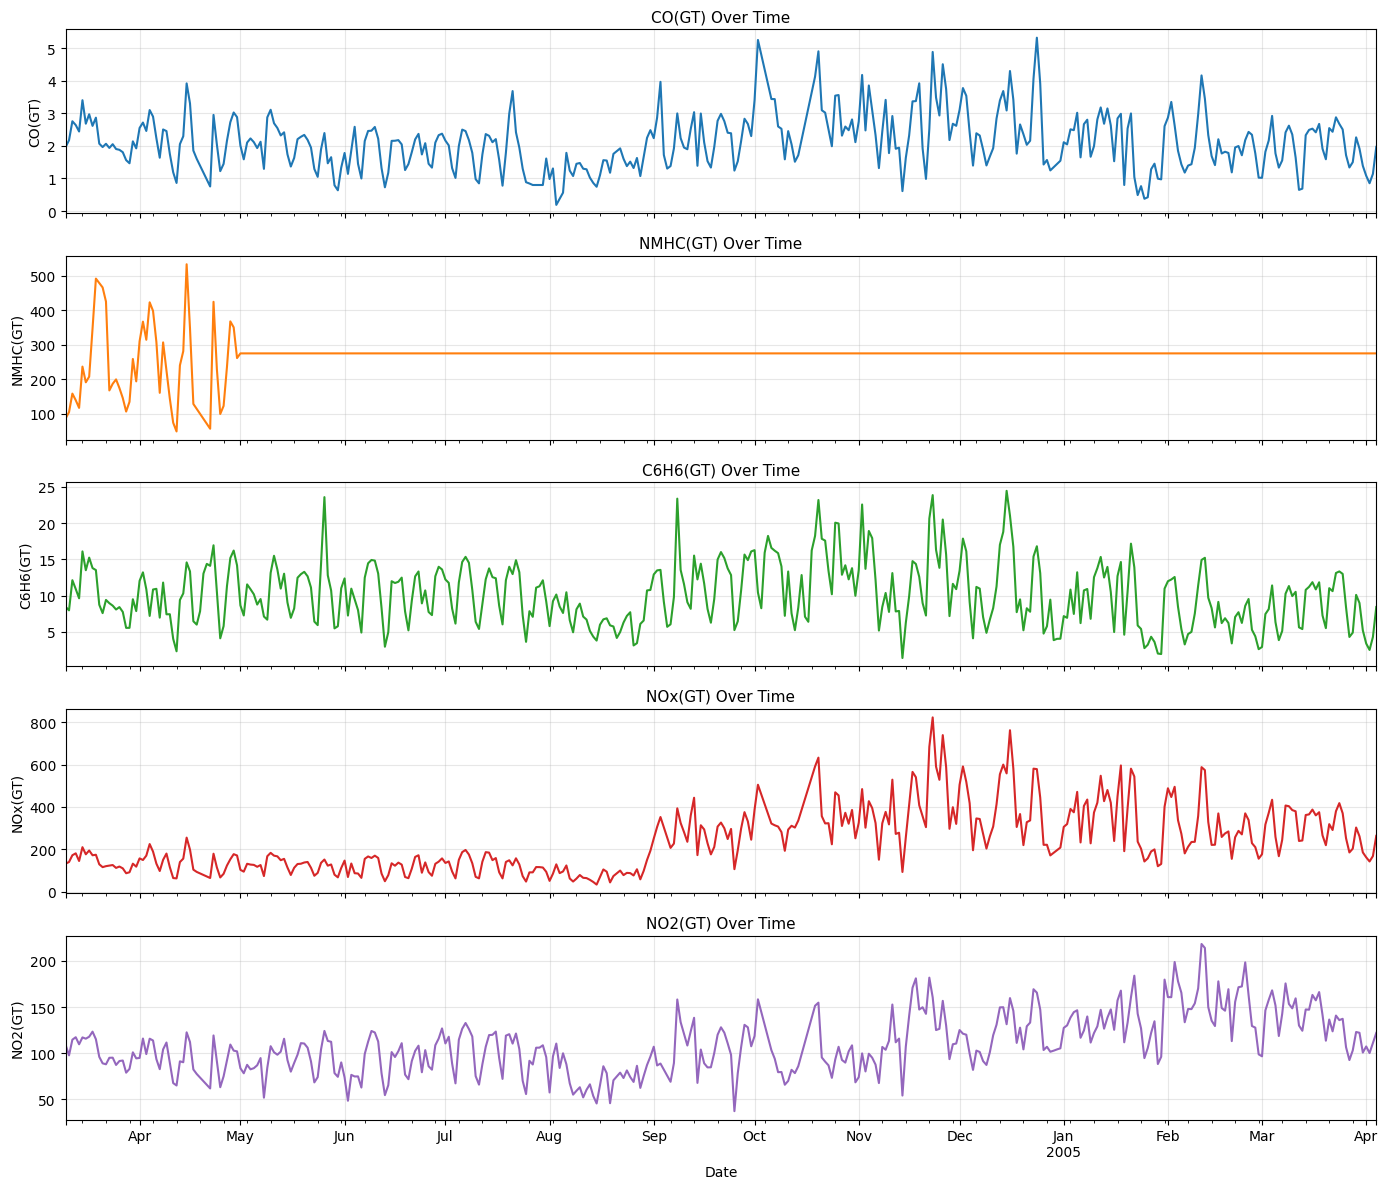

In [16]:
# Select all GT columns
gt_columns = [col for col in data.columns if 'GT' in col]

# Create subplots for each GT column
fig, axes = plt.subplots(len(gt_columns), 1, figsize=(14, 12), sharex=True)

for idx, col in enumerate(gt_columns):
    data[col].resample('D').mean().plot(ax=axes[idx], color=f'C{idx}', linewidth=1.5)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_title(f'{col} Over Time', fontsize=11)

axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.show()

### 3.2 Pollutant Correlations

Analyze the correlation structure among different pollutant measurements. The results show strong positive correlations (> 0.5) between CO, C6H6, NOx, and NO2, suggesting common emission sources or atmospheric chemistry. However, NMHC exhibits problematic correlation patterns due to the excessive missing values mentioned previously.

In [17]:
pollutants = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
data[pollutants].corr()

,CO(GT),NMHC(GT),C6H6(GT),NOx(GT),NO2(GT)
CO(GT),1.000000,0.267501,0.816518,0.791269,0.675795
NMHC(GT),0.267501,1.000000,0.233381,0.141745,0.186728
C6H6(GT),0.816518,0.233381,1.000000,0.655010,0.570252
NOx(GT),0.791269,0.141745,0.655010,1.000000,0.763039
NO2(GT),0.675795,0.186728,0.570252,0.763039,1.000000


### 3.3 Meteorological-Chemical Relationships

Examine the relationships between meteorological variables (Temperature, Relative Humidity, Absolute Humidity) and pollutant concentrations. Key observations include:
- C6H6 shows positive correlation with temperature
- NOx and NO2 exhibit negative correlation with temperature
- NOx demonstrates positive correlation with relative humidity
- NO2 shows strong negative correlation with absolute humidity

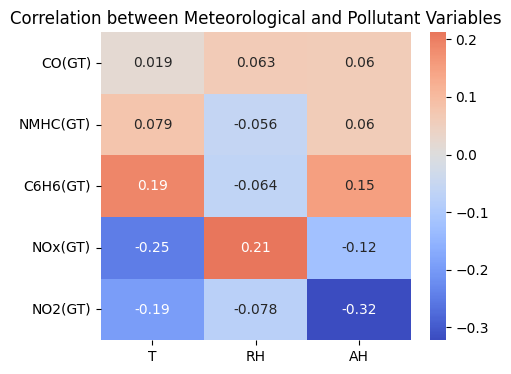

In [18]:
pollutants = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
meteo = ['T', 'RH', 'AH']

corr = data[pollutants + meteo].corr()
corr_meteo = corr.loc[pollutants, meteo]

plt.figure(figsize=(5,4))
sns.heatmap(corr_meteo, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation between Meteorological and Pollutant Variables")
plt.show()

## 4. Train-Test Split

Split the processed dataset into training and test sets based on year:
- Training set: 2004 data
- Test set: 2005 data

This temporal split ensures chronological separation between training and test data.

In [19]:
# Split data by year (using .copy() to avoid SettingWithCopyWarning)
train_data = data[data.index.year == 2004].copy()
test_data = data[data.index.year == 2005].copy()

print(f"Training data (2004):")
print(f"  - Shape: {train_data.shape}")
print(f"  - Date range: {train_data.index.min()} to {train_data.index.max()}")

print(f"\nTest data (2005):")
print(f"  - Shape: {test_data.shape}")
print(f"  - Date range: {test_data.index.min()} to {test_data.index.max()}")

Training data (2004):
  - Shape: (7110, 16)
  - Date range: 2004-03-10 18:00:00 to 2004-12-31 23:00:00

Test data (2005):
  - Shape: (2247, 16)
  - Date range: 2005-01-01 00:00:00 to 2005-04-04 14:00:00


## 5. Feature Normalization

Normalize continuous features (float columns) using StandardScaler fitted on training data only. This prevents data leakage by ensuring test set statistics don't influence the normalization. The same transformation (using training set statistics) is then applied to both training and test sets.

In [20]:
# Identify float columns to normalize
float_columns = train_data.select_dtypes(include=['float64', 'float32', 'float16']).columns.tolist()
int_columns = train_data.select_dtypes(include=['int64', 'int32', 'int16', 'int8']).columns.tolist()

# Fit StandardScaler on training data only
scaler = StandardScaler()
scaler.fit(train_data[float_columns])

# Transform both train and test data using training statistics
train_data[float_columns] = scaler.transform(train_data[float_columns])
test_data[float_columns] = scaler.transform(test_data[float_columns])

## 6. Export Processed Data

Save the normalized training and test datasets to separate CSV files for subsequent analysis and modeling.


In [21]:
# Export to separate CSV files
train_data.to_csv('cleaned_features_train.csv')
test_data.to_csv('cleaned_features_test.csv')

print(f"Training data (2004) saved: cleaned_features_train.csv")
print(f"  - Shape: {train_data.shape}")
print(f"  - Date range: {train_data.index.min()} to {train_data.index.max()}")

print(f"\nTest data (2005) saved: cleaned_features_test.csv")
print(f"  - Shape: {test_data.shape}")
print(f"  - Date range: {test_data.index.min()} to {test_data.index.max()}")


Training data (2004) saved: cleaned_features_train.csv
  - Shape: (7110, 16)
  - Date range: 2004-03-10 18:00:00 to 2004-12-31 23:00:00

Test data (2005) saved: cleaned_features_test.csv
  - Shape: (2247, 16)
  - Date range: 2005-01-01 00:00:00 to 2005-04-04 14:00:00



Forecast horizon: t + 1 hours
Naïve baseline accuracy (train, h=1): 0.9304
Naïve baseline accuracy (test,  h=1): 0.9292

Random Forest accuracy (train, h=1): 1.0000
Random Forest accuracy (test,  h=1): 0.9381

Classification report (Random Forest, test set):
              precision    recall  f1-score   support

        high     0.4706    0.3556    0.4051        45
         low     0.9527    0.9890    0.9705      2099
         mid     0.4545    0.1471    0.2222       102

    accuracy                         0.9381      2246
   macro avg     0.6260    0.4972    0.5326      2246
weighted avg     0.9204    0.9381    0.9252      2246

Confusion matrix (Random Forest, test set):


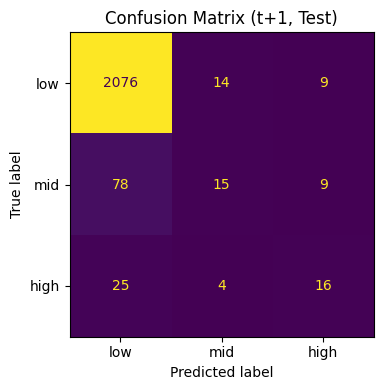

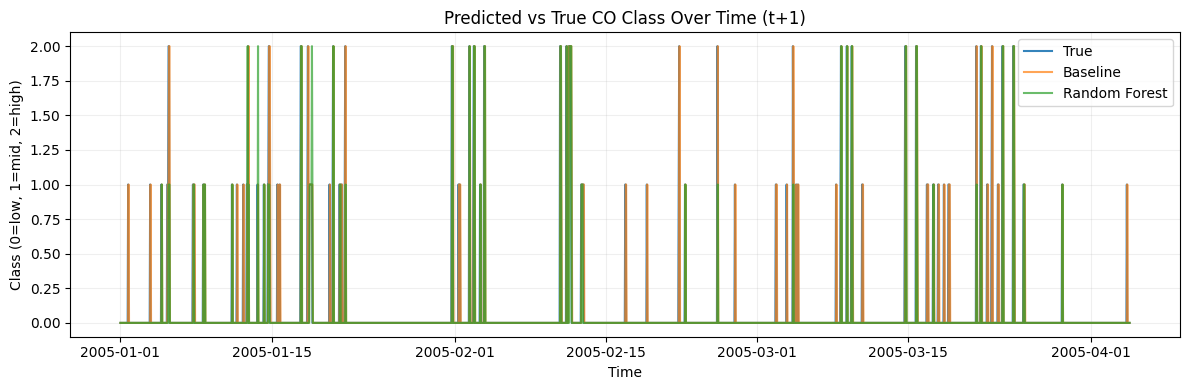


Forecast horizon: t + 6 hours
Naïve baseline accuracy (train, h=6): 0.8715
Naïve baseline accuracy (test,  h=6): 0.8755

Random Forest accuracy (train, h=6): 1.0000
Random Forest accuracy (test,  h=6): 0.9344

Classification report (Random Forest, test set):
              precision    recall  f1-score   support

        high     0.0000    0.0000    0.0000        45
         low     0.9344    1.0000    0.9661      2094
         mid     0.0000    0.0000    0.0000       102

    accuracy                         0.9344      2241
   macro avg     0.3115    0.3333    0.3220      2241
weighted avg     0.8731    0.9344    0.9027      2241

Confusion matrix (Random Forest, test set):


/opt/anaconda3/envs/test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


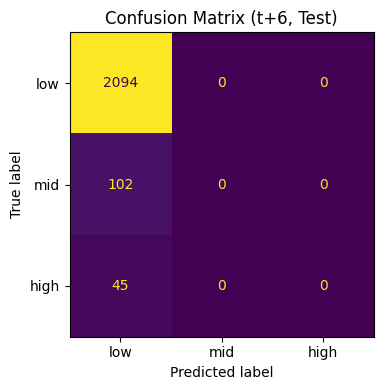

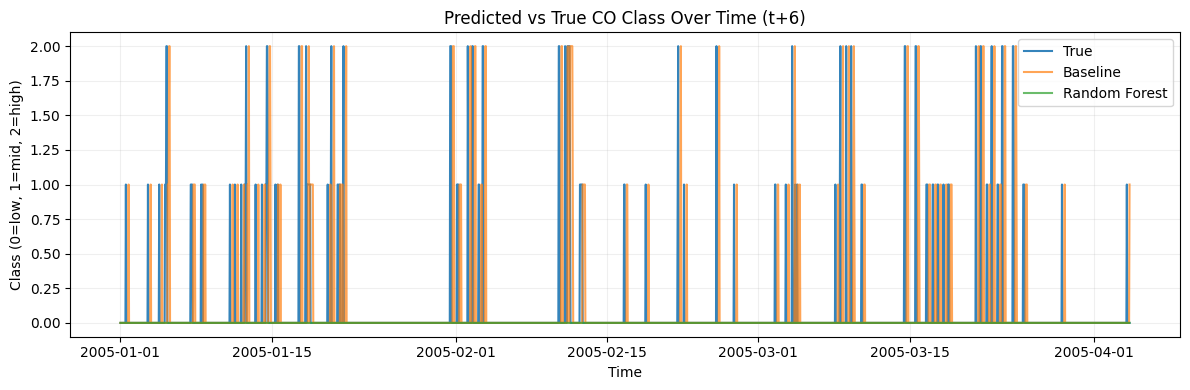


Forecast horizon: t + 12 hours
Naïve baseline accuracy (train, h=12): 0.8671
Naïve baseline accuracy (test,  h=12): 0.8752

Random Forest accuracy (train, h=12): 1.0000
Random Forest accuracy (test,  h=12): 0.9342

Classification report (Random Forest, test set):
              precision    recall  f1-score   support

        high     0.0000    0.0000    0.0000        45
         low     0.9342    1.0000    0.9660      2088
         mid     0.0000    0.0000    0.0000       102

    accuracy                         0.9342      2235
   macro avg     0.3114    0.3333    0.3220      2235
weighted avg     0.8728    0.9342    0.9025      2235

Confusion matrix (Random Forest, test set):


/opt/anaconda3/envs/test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


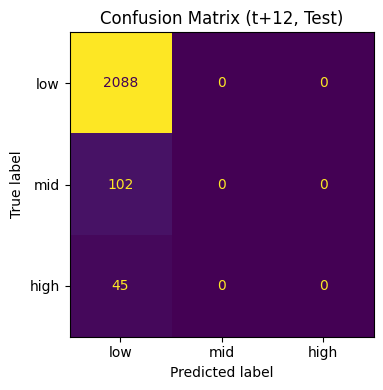

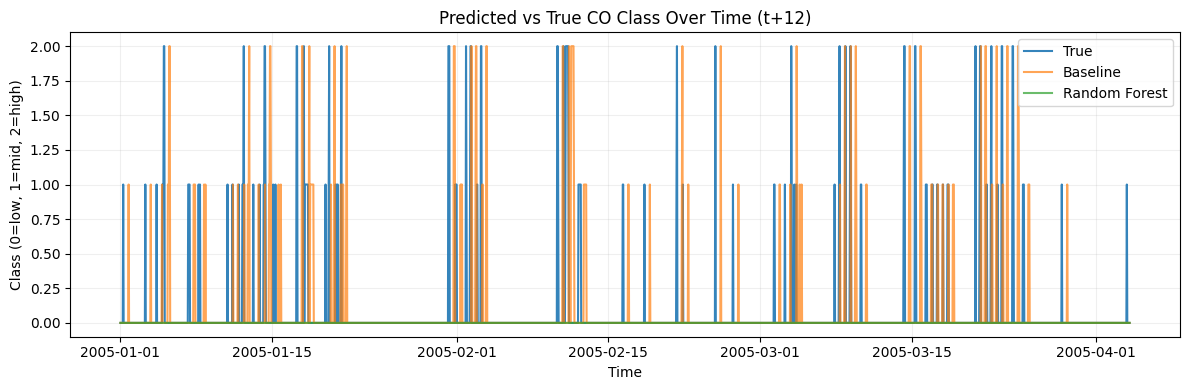


Forecast horizon: t + 24 hours
Naïve baseline accuracy (train, h=24): 0.8868
Naïve baseline accuracy (test,  h=24): 0.9001

Random Forest accuracy (train, h=24): 1.0000
Random Forest accuracy (test,  h=24): 0.9334

Classification report (Random Forest, test set):
              precision    recall  f1-score   support

        high     0.0000    0.0000    0.0000        45
         low     0.9351    0.9990    0.9660      2077
         mid     0.0000    0.0000    0.0000       101

    accuracy                         0.9334      2223
   macro avg     0.3117    0.3330    0.3220      2223
weighted avg     0.8737    0.9334    0.9026      2223

Confusion matrix (Random Forest, test set):


/opt/anaconda3/envs/test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


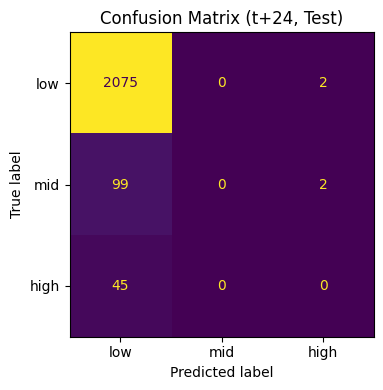

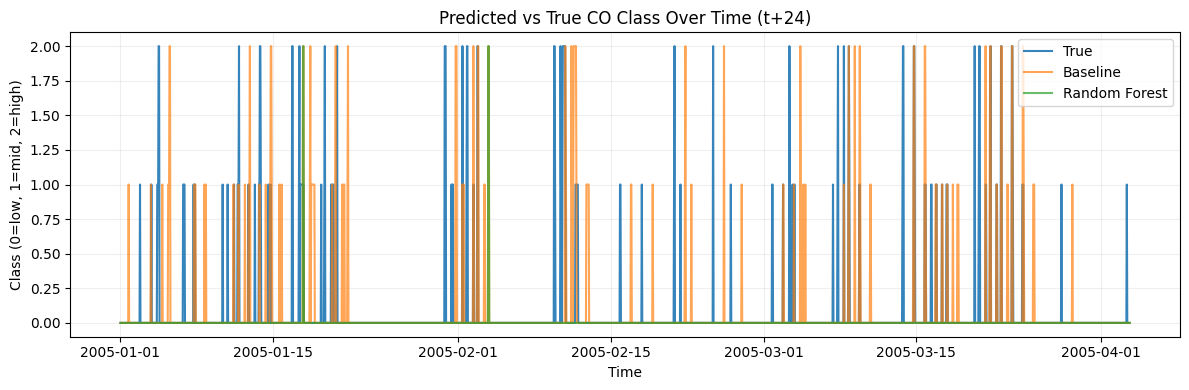

,horizon,baseline_train_acc,baseline_test_acc,rf_train_acc,rf_test_acc
0,1,0.930370,0.929207,1.0,0.938112
1,6,0.871481,0.875502,1.0,0.934404
2,12,0.867146,0.875168,1.0,0.934228
3,24,0.886819,0.900135,1.0,0.933423



Summary:
 horizon  baseline_train_acc  baseline_test_acc  rf_train_acc  rf_test_acc
       1            0.930370           0.929207           1.0     0.938112
       6            0.871481           0.875502           1.0     0.934404
      12            0.867146           0.875168           1.0     0.934228
      24            0.886819           0.900135           1.0     0.933423


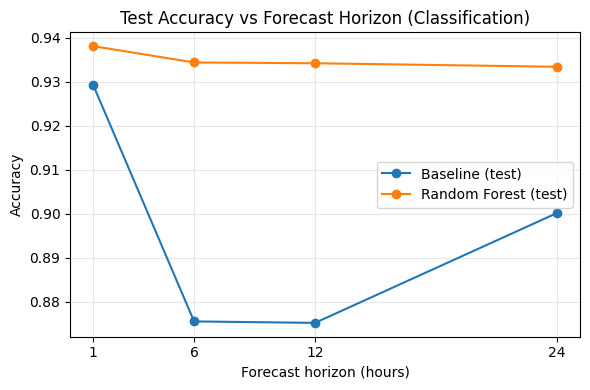

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

def discretize_co(co_series):
    categories = pd.cut(
        co_series,
        bins=[-np.inf, 1.5, 2.5, np.inf],
        labels=["low", "mid", "high"]
    )
    return categories.astype("category")


def make_horizon_classification_df(data, horizon):
    df = data.copy()
    df["CO_cat"] = discretize_co(df["CO(GT)"])
    df["target"] = df["CO_cat"].shift(-horizon)
    df = df.dropna(subset=["target"])
    return df


def encode_co_category(series):
    mapping = {"low": 0, "mid": 1, "high": 2}
    return series.map(mapping).astype(int)

horizons = [1, 6, 12, 24]

rf_models = {}
results = []

for h in horizons:
    print("\n" + "=" * 80)
    print(f"Forecast horizon: t + {h} hours")
    print("=" * 80)

    train_df_h = make_horizon_classification_df(train_data, horizon=h)
    test_df_h  = make_horizon_classification_df(test_data,  horizon=h)

    feature_cols = [c for c in train_df_h.columns if c != "target"]

    X_train = train_df_h[feature_cols].copy()
    y_train = train_df_h["target"].copy()

    X_test = test_df_h[feature_cols].copy()
    y_test = test_df_h["target"].copy()

    # baseline
    baseline_train_pred = train_df_h["CO_cat"].copy()
    baseline_test_pred  = test_df_h["CO_cat"].copy()

    baseline_train_acc = accuracy_score(y_train, baseline_train_pred)
    baseline_test_acc  = accuracy_score(y_test,  baseline_test_pred)

    print(f"Naïve baseline accuracy (train, h={h}): {baseline_train_acc:.4f}")
    print(f"Naïve baseline accuracy (test,  h={h}): {baseline_test_acc:.4f}")

    # random forest
    X_train["CO_cat"] = encode_co_category(X_train["CO_cat"])
    X_test["CO_cat"]  = encode_co_category(X_test["CO_cat"])

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    rf.fit(X_train, y_train)
    rf_models[h] = rf

    y_train_pred = rf.predict(X_train)
    y_test_pred  = rf.predict(X_test)

    rf_train_acc = accuracy_score(y_train, y_train_pred)
    rf_test_acc  = accuracy_score(y_test,  y_test_pred)

    print(f"\nRandom Forest accuracy (train, h={h}): {rf_train_acc:.4f}")
    print(f"Random Forest accuracy (test,  h={h}): {rf_test_acc:.4f}")

    # model assessment
    print("\nClassification report (Random Forest, test set):")
    print(classification_report(y_test, y_test_pred, digits=4))

    print("Confusion matrix (Random Forest, test set):")
    cm = confusion_matrix(y_test, y_test_pred, labels=["low", "mid", "high"])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["low", "mid", "high"]
    )
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix (t+{h}, Test)")
    plt.tight_layout()
    plt.show()

    df_plot = pd.DataFrame({
        "true": encode_co_category(y_test),
        "baseline": encode_co_category(baseline_test_pred),
        "rf": encode_co_category(pd.Series(y_test_pred, index=y_test.index))
    }, index=X_test.index)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df_plot.index, df_plot["true"], label="True", alpha=0.9)
    ax.plot(df_plot.index, df_plot["baseline"], label="Baseline", alpha=0.7)
    ax.plot(df_plot.index, df_plot["rf"], label="Random Forest", alpha=0.7)

    ax.set_title(f"Predicted vs True CO Class Over Time (t+{h})")
    ax.set_xlabel("Time")
    ax.set_ylabel("Class (0=low, 1=mid, 2=high)")
    ax.grid(True, alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.show()


    results.append({
        "horizon": h,
        "baseline_train_acc": baseline_train_acc,
        "baseline_test_acc": baseline_test_acc,
        "rf_train_acc": rf_train_acc,
        "rf_test_acc": rf_test_acc
    })


results_df = pd.DataFrame(results).sort_values("horizon").reset_index(drop=True)
display(results_df)

print("\nSummary:")
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(results_df["horizon"], results_df["baseline_test_acc"],
        marker="o", label="Baseline (test)")
ax.plot(results_df["horizon"], results_df["rf_test_acc"],
        marker="o", label="Random Forest (test)")

ax.set_xticks(results_df["horizon"])
ax.set_xticklabels(results_df["horizon"])
ax.set_xlabel("Forecast horizon (hours)")
ax.set_ylabel("Accuracy")
ax.set_title("Test Accuracy vs Forecast Horizon (Classification)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
